In [1]:
from pyscripts.heavy_atom_rmsd import *

In [2]:
#Explain all json params as they are assinged
#Trajectory file from which to obtain train and test sets
fname_dcd = "/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/1crn_split2.dcd"
#Parameter file for energy functions
fname_topology = "/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/1crn_H.prmtop"
#Number of latent dimensions
latent_dim = 4
#index of the data from which to derive the 20/80 test set split
test_slice = 3
#name for file-keeping purposes
model_name = "CR_BN_Experiment"
#Directory to build outputs
save_dir = "/media/volume/Josephs-Volume/githubs/Deep-MMS/"
#initial and final index of data from which to derive test and train sets
data_slice_start, data_slice_end = 0, "None"
#size of batches (must be an even divisor of total test and total train frames)
batch_size = 1000
#Learning rate for the adam optimizer
learning_rate = 1e-2
#Dropout rates for the hideen layers - also determines the quantity of layers
dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
#Whether to resume a previous training or not
resume_latest = False
#Interval of epochs to checkpoint the Neural Network
checkpoint_interval = 200
#Cutoff epoch
max_epoch = 4010


In [3]:
# json_params = dict(fname_dcd=fname_dcd,
#                    fname_topology=fname_topology,
#                    save_dir=save_dir,
#                    max_epoch=max_epoch,
#                    latent_dim=latent_dim,
#                    test_slice=test_slice,
#                    data_slice_start=data_slice_start,
#                    data_slice_end=data_slice_end,
#                    model_name=model_name,
#                    batch_size=batch_size,
#                    learning_rate=learning_rate,
#                    dropout_rates=dropout_rates, 
#                    resume_latest=resume_latest, 
#                    checkpoint_interval=checkpoint_interval,
#                    is_batchnorm=is_batchnorm)

### Perform a Crambin Experiment

Take BatchNorm Layers in or out\
Vary the depth\
vary the presence of dropout\
vary the learning rate

In [4]:
#Naming convention BN(T/F)_DO(T/F)_Dpth(int)_lr(pInt)
#i.e. BN is True or False, Dropout is True or False, Depth is an integer and lr is the -log(lr)
import numpy as np
dropout_sets = [[0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1],
                [0.5, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1],
                [0.5, 0.4, 0.3, 0.2, 0.1, 0.1],
                [0.4, 0.3, 0.2, 0.1]]

is_dropout = True

for is_batchnorm in [True, False]:
    for dropout_set in dropout_sets:
        for test_slice in [0, 2, 4]:
            for lr in [1e-2, 1e-3, 1e-4, 1e-5]:
                #Naming convention BN(T/F)_DO(T/F)_Dpth(int)_lr(pInt)
                #i.e. BN is True or False, Dropout is True or False, Depth is an integer and lr is the -log(lr)
                experiment_name = f"BN_{is_batchnorm}_rpt_{test_slice}_Dpth_{len(dropout_set)}_lr_{int(-1*np.log10(lr))}"
                data_dir = os.path.join(save_dir, model_name, experiment_name)

                json_params = dict(fname_dcd="/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/1crn_split2.dcd",
                                   fname_topology="/media/volume/Josephs-Volume/githubs/Deep-MMS/Simulation/1crn_H.prmtop",
                                   save_dir="/media/volume/Josephs-Volume/githubs/Deep-MMS/",
                                   max_epoch=3000,
                                   latent_dim=128,
                                   test_slice=test_slice,
                                   data_slice_start=0,
                                   data_slice_end="None",
                                   model_name=model_name,
                                   batch_size=1000,
                                   learning_rate=lr,
                                   dropout_rates=dropout_set, 
                                   resume_latest=False, 
                                   checkpoint_interval=200,
                                   is_batchnorm=is_batchnorm,
                                   data_dir=data_dir)
                
                json_fn = f'/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/{model_name}/{experiment_name}.json'
                if not os.path.exists(f'/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/{model_name}'):
                    os.makedirs(f'/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/{model_name}', exist_ok=True)
                with open(json_fn, 'w') as f:
                    json.dump(json_params, f, indent=4)

In [6]:
#self = HeavyAtom_NN_Experiment('json_inputs/CR_Hyper_Param_Experiment/BN_True_DO_False_Dpth_4_lr_3.json')
import glob
sorted(glob.glob('/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/*.json'))

['/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_10_lr_2.json',
 '/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_10_lr_3.json',
 '/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_10_lr_4.json',
 '/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_10_lr_5.json',
 '/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_4_lr_2.json',
 '/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_4_lr_3.json',
 '/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_4_lr_4.json',
 '/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_4_lr_5.json',
 '/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_BN_Experiment/BN_False_rpt_0_Dpth_6_lr_2.json

In [2]:
HeavyAtom_NN_Experiment('/media/volume/Josephs-Volume/githubs/Deep-MMS/json_inputs/CR_Hyper_Param_Experiment/BN_False_DO_True_Dpth_4_lr_3.json', from_json_params=False)

10/29/2025 20:04:55//Load Files
10/29/2025 20:04:55//Establish Directories
10/29/2025 20:04:55//Load Data with MDTraj
10/29/2025 20:04:56//Batch data
10/29/2025 20:04:57//((8000, 981), (2000, 981))
10/29/2025 20:04:57//Model Init
10/29/2025 20:05:07//Checkpointer


10/29/2025 20:05:07//Batch Data
10/29/2025 20:05:07//Establish NCs
10/29/2025 20:05:07//Epoch 0
10/29/2025 20:05:07//NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
10/29/2025 20:05:07//Model BatchNorm_VAE(
    # attributes
    input_size = 981
    hidden_layers = [981, 784, 510, 128]
    latents = 128
    dropout_rates = [0.4, 0.3, 0.2, 0.1]
    is_batchnorm = False
)
10/29/2025 20:05:07//INITIALIZATION COMPLETE


In [4]:
start = datetime.now()
#json_params['latent_dim'] = latent_n
self = HeavyAtom_NN_Experiment(json_params, from_json_params=True)
self.MAIN_train(n_epochs=200, verbose=100)
train_time = datetime.now() - start
printf(f"Time to train {self.n_latents} model for {self.epoch} epochs was {train_time} averaging {train_time/self.epoch} per epoch.") 

09/03/2025 22:01:49//Load Files
09/03/2025 22:01:49//Establish Directories
09/03/2025 22:01:49//Load Data with MDTraj
09/03/2025 22:01:51//Batch data
09/03/2025 22:01:51//((8000, 981), (2000, 981))
09/03/2025 22:01:51//Model Init
09/03/2025 22:02:08//Checkpointer


09/03/2025 22:02:08//Batch Data
09/03/2025 22:02:08//Establish NCs
09/03/2025 22:02:08//Epoch 0
09/03/2025 22:02:08//NC <class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
09/03/2025 22:02:08//Model BatchNorm_VAE(
    # attributes
    input_size = 981
    hidden_layers = [981, 914, 839, 756, 662, 558, 442, 311, 166, 4]
    latents = 4
    dropout_rates = [0.5, 0.4, 0.4, 0.3, 0.3, 0.2, 0.2, 0.1, 0.1, 0.1]
)
09/03/2025 22:02:08//INITIALIZATION COMPLETE
09/03/2025 22:02:56//Epoch      0 took: 0:00:48.331469
09/03/2025 22:02:57//		RMSD_Term	Train=NAN	Test=NAN
09/03/2025 22:03:05//Epoch    100 took: 0:00:00.088048
09/03/2025 22:03:05//		RMSD_Term	Train=1.203E-01	Test=1.201E-01
09/03/2025 22:03:14//Epoch    200 took: 0:00:00.694449
09/03/2025 22:03:14//		RMSD_Term	Train=1.283E-01	Test=1.280E-01
09/03/2025 22:03:23//Epoch    300 took: 0:00:00.093927
09/03/2025 22:03:23//		RMSD_Term	Train=1.222

In [5]:
traingrp = self.rootgrp['Train']
testgrp = self.rootgrp['Test']

rmsd_train = np.mean(traingrp['RMSD_Loss_Term'][:, :], axis=-1)
rmsd_test  = np.mean(testgrp['RMSD_Loss_Term'][:, :], axis=-1)
#kl_train   = np.mean(traingrp['KL_Loss_Term'][:, :], axis=-1)
#kl_test    = np.mean(testgrp['KL_Loss_Term'][:, :], axis=-1)
#mi_train   = np.mean(traingrp['MI_Loss_Term'][:, :], axis=-1)
#mi_test    = np.mean(testgrp['MI_Loss_Term'][:, :], axis=-1)


In [6]:
f"Final Epoch {self.epoch} Train RMSD:{rmsd_train[-1]*10:2.3f} A, Test RMSD:{rmsd_test[-1]*10:2.3f} A"

'Final Epoch 4010 Train RMSD:0.856 A, Test RMSD:0.867 A'

In [7]:
figure_dir = os.path.join(self.data_dir, 'figures')
if not os.path.isdir(figure_dir):
    os.mkdir(figure_dir)

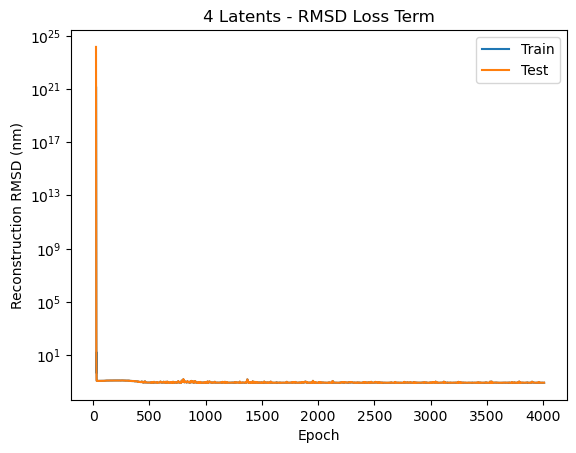

In [8]:
#RMSD TERM
plt.clf()
_ = plt.plot(np.arange(len(rmsd_train)), rmsd_train, label='Train')
_ = plt.plot(np.arange(len(rmsd_test)), rmsd_test, label='Test')
plt.legend()
#plt.ylim(1, 10)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction RMSD (nm)')
title = f"{self.n_latents} Latents - RMSD Loss Term"
plt.title(title)
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

In [9]:
# #KL TERM
# plt.clf()
# _ = plt.plot(np.arange(len(kl_train)), kl_train, label='Train')
# _ = plt.plot(np.arange(len(kl_test)), kl_test, label='Test')
# plt.legend()
# #plt.ylim(1, 10)
# plt.yscale('log')
# plt.xlabel('Epoch')
# plt.ylabel('KL Loss')
# title = f"{self.n_latents} Latents - KL Loss Term"
# plt.title(title)
# #plt.savefig(f"{self.model_name}/figures/{title.replace(' ', '_')}.png", dpi=900)
# plt.show()

In [10]:
# #MI TERM
# plt.clf()
# _ = plt.plot(np.arange(len(mi_train)), mi_train, label='Train')
# _ = plt.plot(np.arange(len(mi_test)), mi_test, label='Test')
# plt.legend()
# #plt.ylim(1, 10)
# plt.yscale('log')
# plt.xlabel('Epoch')
# plt.ylabel('MI Loss')
# title = f"{self.n_latents} Latents - MI Loss Term"
# plt.title(title)
# #plt.savefig(f"{self.model_name}/figures/{title.replace(' ', '_')}.png", dpi=900)
# plt.show()

In [11]:
# #Full Loss
# plt.clf()
# _ = plt.plot(np.arange(len(kl_train)), rmsd_train + kl_train, label='Train')
# _ = plt.plot(np.arange(len(kl_test)), rmsd_test + kl_test, label='Test')
# plt.legend()
# #plt.ylim(1, 10)
# plt.yscale('log')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# title = f"{self.n_latents} Latents - Full Loss Function"
# plt.title(title)
# #plt.savefig(f"{self.model_name}/figures/{title.replace(' ', '_')}.png", dpi=900)
# plt.show()

In [12]:
root_key = jax.random.PRNGKey(self.epoch)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)
decoded, latent_means, latent_vars = self.state.apply_fn({'params':self.state.params,
                                                          'batch_stats':self.state.batch_stats},
                                                         self.test_data,
                                                         main_key,
                                                         train=False,
                                                         rngs={'params': params_key,
                                                               'dropout': dropout_key})
print(decoded.shape, latent_means.shape, latent_vars.shape)

(2000, 981) (2000, 4) (2000, 4)


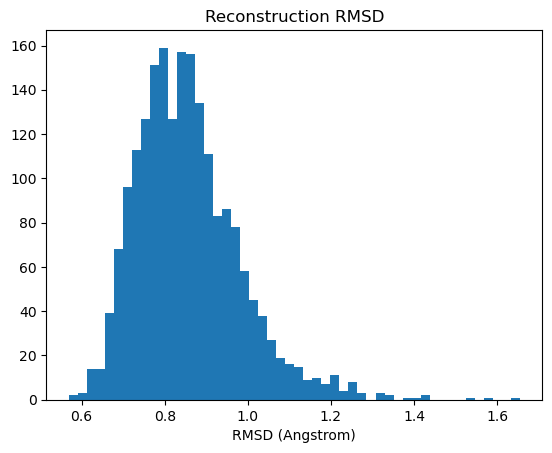

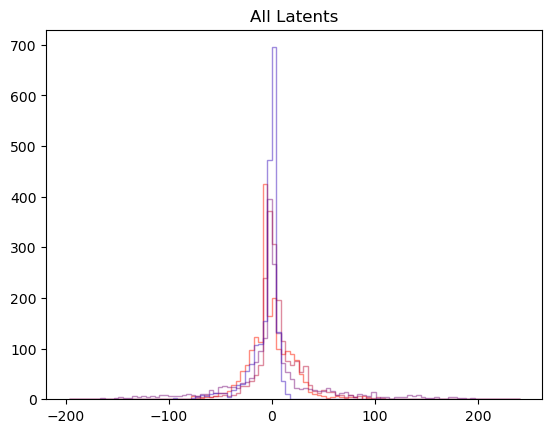

In [13]:
#Plot the rmsd histogram of decoded to encoded
rmsd_vals = atom_rmsd(self.test_data, decoded)*10
plt.clf()
_ = plt.hist(rmsd_vals, bins=50)
title = "Reconstruction RMSD"
plt.title(title)
plt.xlabel("RMSD (Angstrom)")
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

#Plot the latent dimensional distributions
colors = [(i/self.n_latents, 0.1, (self.n_latents - i)/self.n_latents) for i in range(1, self.n_latents+1)]
plt.clf()
_ = plt.hist(latent_means, bins=100, histtype='step', alpha=0.5, color=colors)
title = 'All Latents'
plt.title(title)
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

/home/exouser/miniconda3/envs/jax_GPU/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/exouser/miniconda3/envs/jax_GPU/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/exouser/miniconda3/envs/jax_GPU/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/exouser/miniconda3/envs/jax_GPU/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A colu

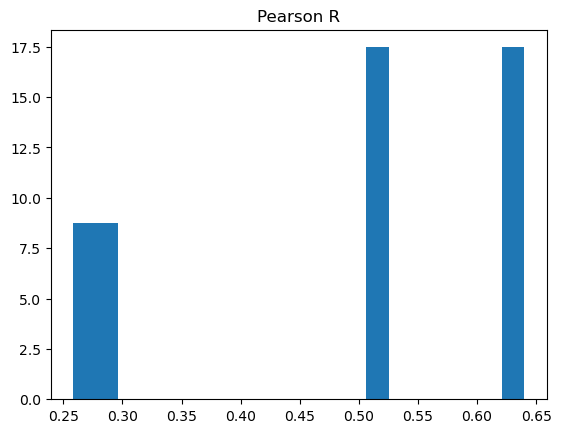

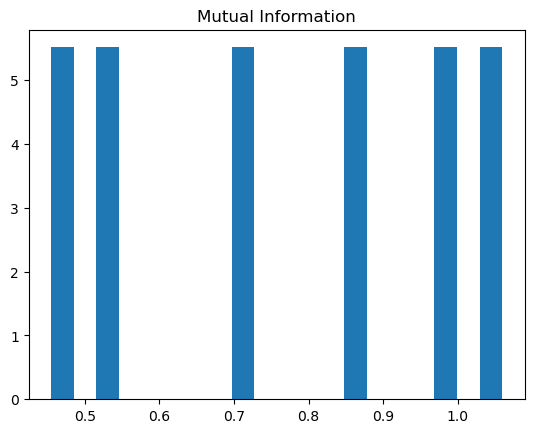

In [14]:
#Calculate MI/correlation metrics
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
pearson_Rs = []
MI_regressions = []
for i in range(self.n_latents):
    for j in range(i+1, self.n_latents):
        pearson_Rs.append(stats.pearsonr(latent_means[:, i], latent_means[:, j])[0])
        MI_regressions.append(mutual_info_regression(latent_means[:, i].reshape(-1, 1),
                                                     latent_means[:, j].reshape(-1, 1))[0])
pearson_Rs = jnp.array(pearson_Rs)
MI_regressions = jnp.array(MI_regressions)
#Plot distribution of pearsons R's between latents
plt.clf()
_ = plt.hist(jnp.abs(pearson_Rs), density=True, bins=20)
title = 'Pearson R'
plt.title(title)
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()
#Plot distribution of Mutual Informations between latents
plt.clf()
_ = plt.hist(MI_regressions, density=True, bins=20)
title = 'Mutual Information'
plt.title(title)
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

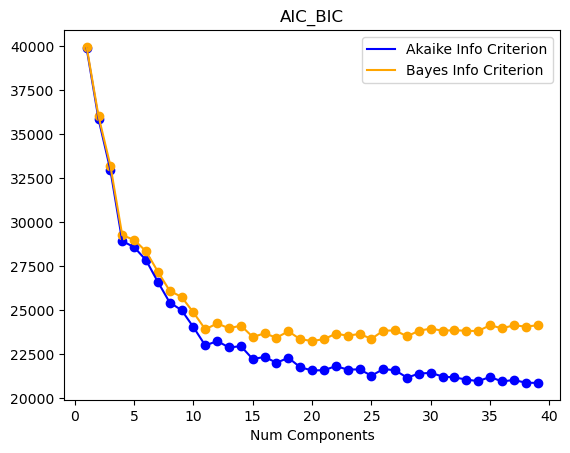

In [43]:
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import jensenshannon
# decoded, latent_means, latent_vars = self.state.apply_fn({'params':self.state.params,
#                                                           'batch_stats':self.state.batch_stats},
#                                                           self.test_data,
#                                                           main_key,
#                                                           train=False,
#                                                           rngs={'params': params_key,
#                                                                 'dropout': dropout_key})
ics = []
for i in range(1, 40):
    MM = GaussianMixture(n_components=i).fit(latent_means)
    ics.append((i, MM.aic(latent_means), MM.bic(latent_means)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1], color='blue', label='Akaike Info Criterion')
_ = plt.scatter(ics[:, 0], ics[:, 1], color='blue')
_ = plt.plot(ics[:, 0], ics[:, 2], color='orange', label='Bayes Info Criterion')
_ = plt.scatter(ics[:, 0], ics[:, 2], color='orange')
plt.legend()
title = "AIC_BIC"
plt.title(title)
plt.xlabel('Num Components')
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

In [45]:
ics[:, 2]

array([39958.46709866, 36031.36952639, 33219.83502524, 29265.03873   ,
       29004.08028205, 28353.28924315, 27201.7334591 , 26110.23341991,
       25761.46645691, 24879.1653328 , 23921.66971093, 24257.24438334,
       23978.94052022, 24134.80564374, 23487.57923149, 23693.21880062,
       23445.49216182, 23810.53634875, 23358.88760126, 23260.41014987,
       23360.89192899, 23673.52477039, 23560.79780362, 23658.56988342,
       23383.05424514, 23843.44376587, 23859.64021763, 23524.26759495,
       23839.10300299, 23964.13263685, 23840.56920943, 23872.87747327,
       23836.08097705, 23826.91769956, 24154.62961283, 23978.94622332,
       24148.70408247, 24078.2509563 , 24148.82993067])

In [46]:
np.argmin(ics[:, 2])+1

20

In [48]:

component_nums

[1, 2, 39, 20]

In [31]:
num_components = 1
MM = GaussianMixture(n_components=num_components).fit(latent_means)
samples, _ = MM.sample(latent_means.shape[0]*50)

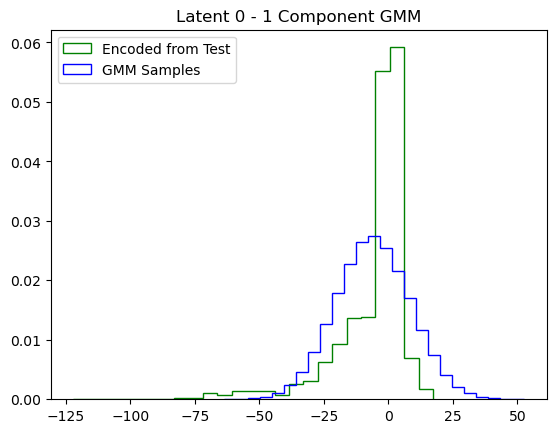

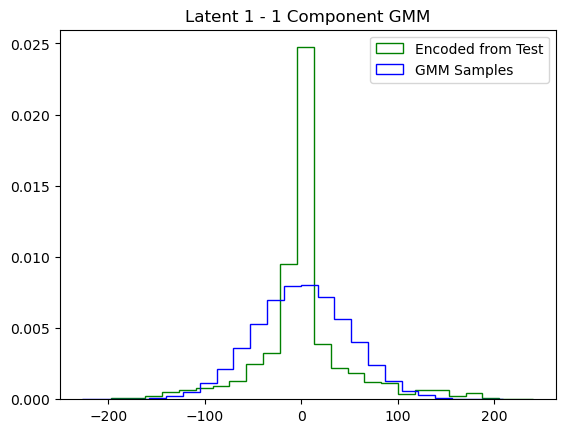

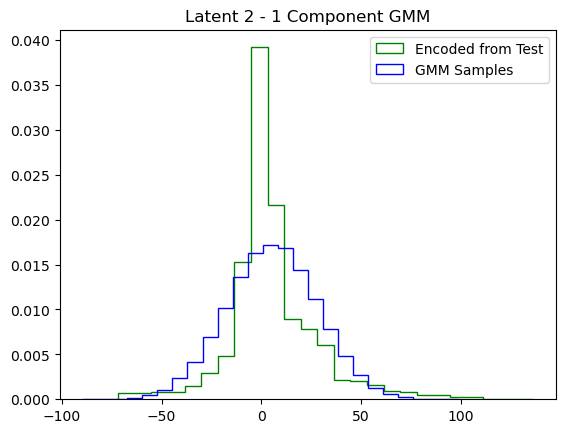

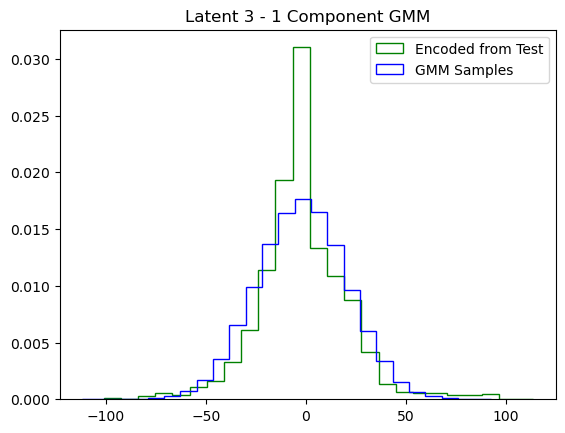

In [32]:
if not os.path.isdir(os.path.join(figure_dir, 'GMM_hists')):
    os.mkdir(os.path.join(figure_dir, 'GMM_hists'))

for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latent_means[:,i], bins=25, histtype='step', color='g', label='Encoded from Test', density=True)
    _ = plt.hist(samples[:,i], bins=25, histtype='step', color='b', label='GMM Samples', density=True)
    title = f'Latent {i} - {num_components} Component GMM'
    plt.title(title)
    plt.legend()
    plt.savefig(os.path.join(figure_dir, 'GMM_hists', title+'.png'), dpi=900, bbox_inches='tight')
    plt.show()

In [33]:
key = jax.random.PRNGKey(self.epoch)
main_key, dropout_key = jax.random.split(key, num=2)

decoded_samples, _ = self.state.apply_fn({'params': self.state.params, 'batch_stats': self.state.batch_stats},
                                      samples, main_key, train=False,
                                      method=self.model.decode,
                                      rngs={'dropout': dropout_key}, mutable=['batch_stats'])
print(self.test_data.shape, latent_means.shape, decoded.shape, samples.shape, decoded_samples.shape)

(2000, 981) (2000, 4) (2000, 981) (100000, 4) (100000, 981)


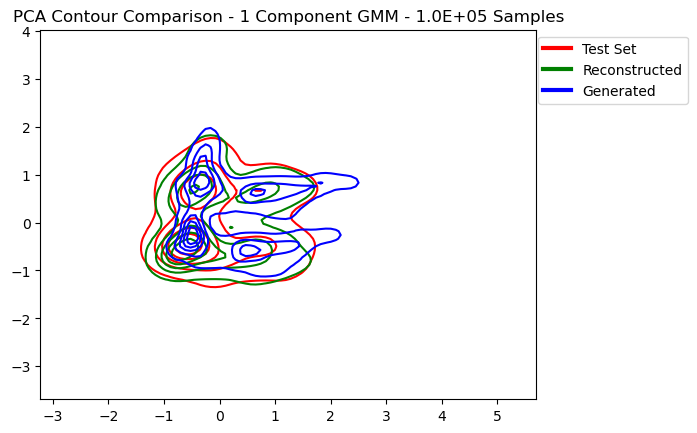

In [34]:
# Contour plot of Test Data, Reconstructed Data, and Generated Data
fit_all, fit_test = False, True

from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
if fit_all:
    pca.fit(jnp.concatenate((self.test_data, decoded, decoded_samples)))
    pca_test = pca.transform(self.test_data)
elif fit_test:
    pca_test = pca.fit_transform(self.test_data)
pca_recon = pca.transform(decoded)
pca_gener = pca.transform(decoded_samples)

names = ["Test Set", "Reconstructed", "Generated"]
colors = ['red', 'green', 'blue']
xx, yy = np.meshgrid(np.linspace(pca_test[:,0].min()-2, pca_test[:,0].max()+2, 100),
                     np.linspace(pca_test[:,1].min()-2, pca_test[:,1].max()+2, 100))

custom_lines = []
for i, data in enumerate([pca_test, pca_recon, pca_gener]):
    kde = gaussian_kde(data.T)
    z = kde(np.vstack([xx.flatten(), yy.flatten()]))
    z = z.reshape(xx.shape)
    levels = np.linspace(z.max()*0.05, z.max(), 6)
    plt.contour(xx, yy, z, colors=colors[i], levels=levels)
    custom_lines.append(plt.Line2D([0], [0], color=colors[i], lw=3))
lgd = plt.legend(custom_lines, names, bbox_to_anchor=(1.32,1))
title = f'PCA Contour Comparison - {num_components} Component GMM - {decoded_samples.shape[0]:1.1E} Samples'
plt.title(title)
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

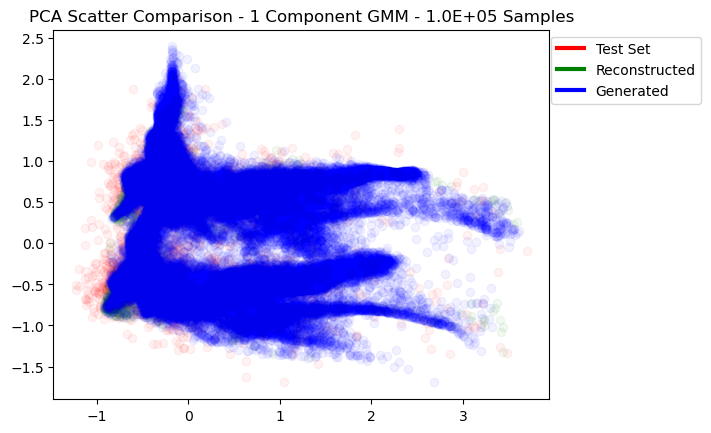

In [35]:
plt.clf()
custom_lines = []
for i, data in enumerate([pca_test, pca_recon, pca_gener]):
    plt.scatter(data[:,0], data[:,1], color=colors[i], label=names[i], alpha=0.05)
    custom_lines.append(plt.Line2D([0], [0], color=colors[i], lw=3))
lgd = plt.legend(custom_lines, names, bbox_to_anchor=(1.32,1))
title = f'PCA Scatter Comparison - {num_components} Component GMM - {decoded_samples.shape[0]:1.1E} Samples'
plt.title(title)
plt.savefig(os.path.join(figure_dir, title+'.png'), dpi=900, bbox_inches='tight')
plt.show()

In [1]:
import numpy as np

In [18]:
n_latent_dims = 12
1 * 10**(-2 - 0.8*np.log10(2**np.arange(n_latent_dims)))

array([1.00000000e-02, 5.74349177e-03, 3.29876978e-03, 1.89464571e-03,
       1.08818820e-03, 6.25000000e-04, 3.58968236e-04, 2.06173111e-04,
       1.18415357e-04, 6.80117628e-05, 3.90625000e-05, 2.24355147e-05])

array([0.        , 0.30103   , 0.60205999, 0.90308999, 1.20411998,
       1.50514998, 1.80617997, 2.10720997, 2.40823997, 2.70926996,
       3.01029996, 3.31132995, 3.61235995])

array([-2.        , -2.30103   , -2.60205999, -2.90308999, -3.20411998,
       -3.50514998, -3.80617997, -4.10720997, -4.40823997, -4.70926996,
       -5.01029996, -5.31132995, -5.61235995])